## Mount Google Drive

In [56]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## Set Project Directory

In [57]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/rocket_telemetry_project"

os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/rocket_telemetry_project


## Imports

In [58]:
import os
import json
import ast
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

## Create Result Directorie

In [59]:
os.makedirs("results", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)

## Define Channel

In [60]:
channel_id = "P-1"

## Load Anomaly Intervals

In [61]:
labels_df = pd.read_csv("data/labeled_anomalies.csv")

row = labels_df[labels_df["chan_id"] == channel_id].iloc[0]

intervals = ast.literal_eval(row["anomaly_sequences"])

print("Intervals:", intervals)

Intervals: [[2149, 2349], [4536, 4844], [3539, 3779]]


## Extract Variables From Threshold Notebook

In [62]:
window_size = threshold_module.window_size

errors = threshold_module.test_errors

# choose prediction method
y_pred = threshold_module.y_pred_dynamic
# or
# y_pred = threshold_module.y_pred_percentile

## Align Window Labels

In [63]:
n_test_timesteps = threshold_module.X_test_seq.shape[0] + window_size

y_true_aligned = align_window_labels(
    intervals,
    n_test_timesteps,
    window_size
)

print("Aligned labels:", y_true_aligned.shape)
print("Predictions:", y_pred.shape)
print("Errors:", errors.shape)

Aligned labels: (8464,)
Aligned labels: (8464,)
Predictions: (8464,)
Errors: (8464,)


## Safety Check

In [64]:
assert len(y_true_aligned) == len(y_pred), \
    f"Label mismatch: {len(y_true_aligned)} vs {len(y_pred)}"

assert not np.isnan(errors).any()

print("Evaluation inputs verified.")

Evaluation inputs verified.


## Evaluation Function

In [65]:
def evaluate_channel(channel_id, y_true_al, y_pred, errors):

    assert len(y_true_al) == len(y_pred)

    report = classification_report(
        y_true_al,
        y_pred,
        target_names=["Normal","Anomaly"],
        output_dict=True
    )

    precision = report["Anomaly"]["precision"]
    recall = report["Anomaly"]["recall"]
    f1 = report["Anomaly"]["f1-score"]

    roc_auc = roc_auc_score(y_true_al, errors)
    pr_auc = average_precision_score(y_true_al, errors)

    cm = confusion_matrix(y_true_al, y_pred)

    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "channel": channel_id,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn)
    }

    save_path = f"results/metrics/{channel_id}_eval.json"

    with open(save_path, "w") as f:
        json.dump(metrics, f, indent=4)

    print("Saved metrics →", save_path)

    return metrics, cm

##  ROC Curve Function

In [66]:
def plot_roc_curve(y_true_al, errors, channel_id):

    fpr, tpr, _ = roc_curve(y_true_al, errors)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve — {channel_id}")

    plt.legend()

    plt.savefig(f"results/plots/{channel_id}_roc.png")

    plt.show()

## Precision Recall Curve Function

In [67]:
def plot_precision_recall(y_true_al, errors, channel_id):

    precision, recall, _ = precision_recall_curve(y_true_al, errors)

    pr_auc = average_precision_score(y_true_al, errors)

    anomaly_ratio = y_true_al.mean()

    plt.figure(figsize=(6,5))

    plt.plot(recall, precision, label=f"AP={pr_auc:.3f}")

    plt.axhline(y=anomaly_ratio, linestyle="--", label="No Skill")

    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.title(f"Precision-Recall Curve — {channel_id}")

    plt.legend()

    plt.savefig(f"results/plots/{channel_id}_pr_curve.png")

    plt.show()

## Confusion Matrix Function

In [68]:
def plot_confusion_matrix(cm, channel_id, f1):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal","Anomaly"],
        yticklabels=["Normal","Anomaly"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(f"{channel_id} Confusion Matrix — F1={f1:.3f}")

    plt.savefig(f"results/plots/{channel_id}_cm.png")

    plt.show()

## Run Evaluation

Saved metrics → results/metrics/P-1_eval.json


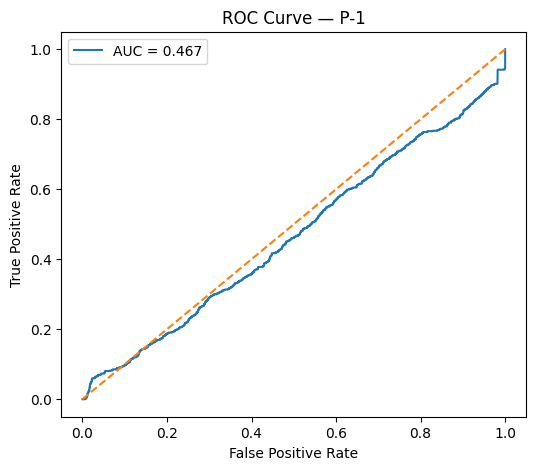

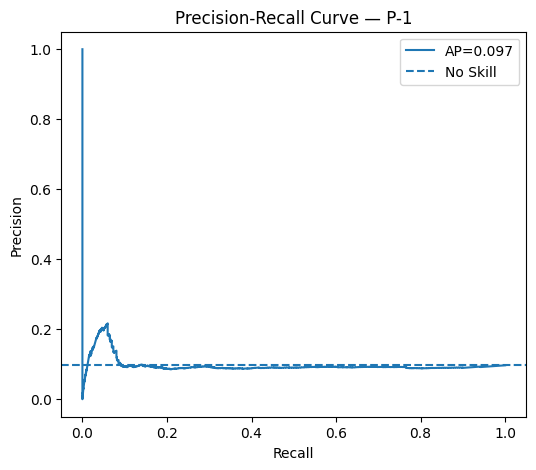

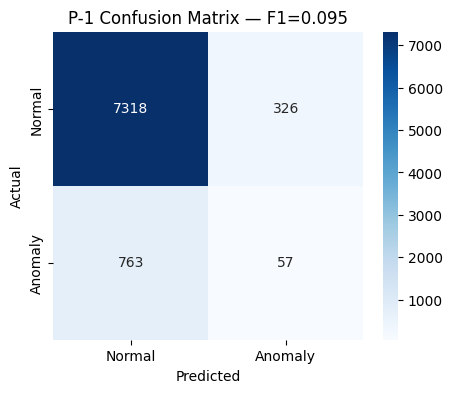

In [69]:
metrics, cm = evaluate_channel(
    channel_id,
    y_true_aligned,
    y_pred,
    errors
)

plot_roc_curve(y_true_aligned, errors, channel_id)

plot_precision_recall(y_true_aligned, errors, channel_id)

plot_confusion_matrix(cm, channel_id, metrics["f1_score"])

## PR Curve Importance

### Why Precision-Recall Curve Matters

### The dataset contains roughly 10% anomalies.

### ROC curves can appear very strong even when anomaly detection is weak.

### Precision-Recall curves focus on the anomaly class and therefore give a more realistic view of model performance on imbalanced datasets.